R² Score: 0.98
MAE: 20.46 kVA


C:\Users\Golden\AppData\Local\Temp\ipykernel_3360\1656237789.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[X.columns[i] for i in indices], ax=axes[2], palette='viridis')


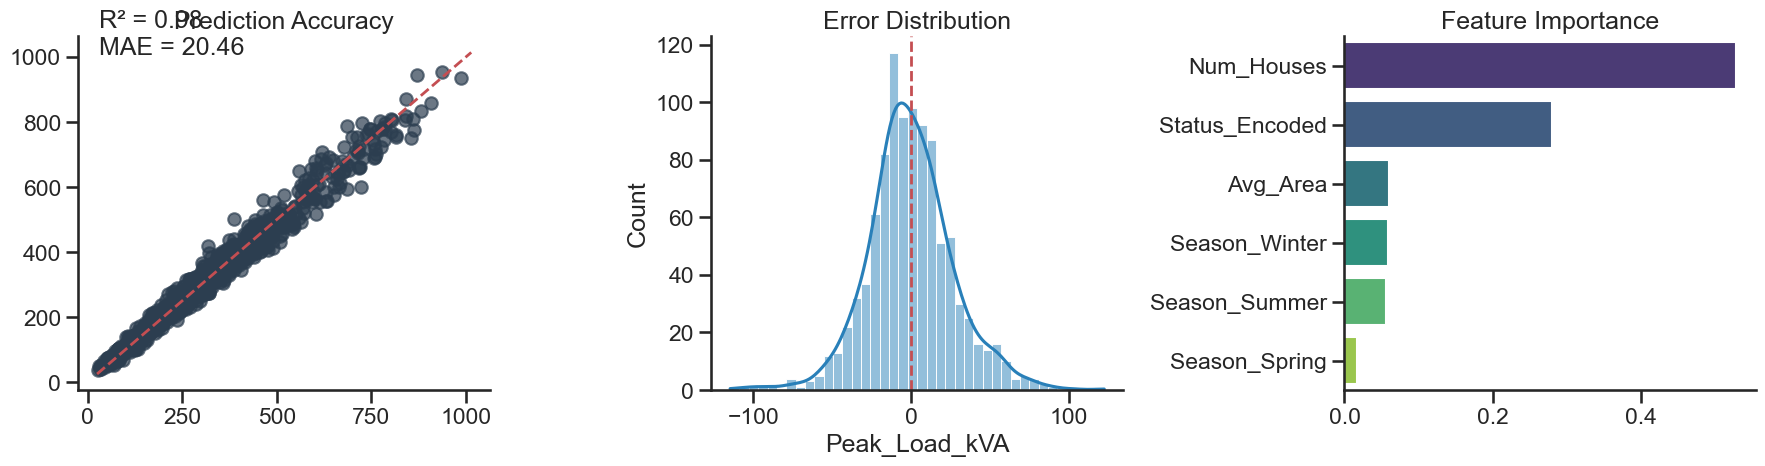

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Data Preparation
df = pd.read_csv('transformer_data.csv')
df['Status_Encoded'] = df['Status'].map({'Low': 1, 'Middle': 2, 'High': 3})
df = pd.get_dummies(df, columns=['Season'], drop_first=True)

X = df.drop(columns=['Peak_Load_kVA', 'Transformer_Size_kVA', 'Status'])
y = df['Peak_Load_kVA']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Model Training
rf_model = RandomForestRegressor(n_estimators=100, max_depth=8, min_samples_split=5, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Prediction & Evaluation
y_test_pred = rf_model.predict(X_test)

r2_test = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"R² Score: {r2_test:.2f}")
print(f"MAE: {mae_test:.2f} kVA")

# 4. Visualization
sns.set_theme(style="ticks", context="talk")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_test_pred, alpha=0.7, color='#2c3e50')
axes[0].plot([y.min(), y.max()],[y.min(), y.max()], 'r--', lw=2)
axes[0].set_title('Prediction Accuracy')
axes[0].text(0.05, 0.95, f'R² = {r2_test:.2f}\nMAE = {mae_test:.2f}', transform=axes[0].transAxes, bbox=dict(facecolor='white', alpha=0.8))

# Plot 2: Residuals
sns.histplot(y_test - y_test_pred, kde=True, ax=axes[1], color='#2980b9')
axes[1].axvline(0, color='r', linestyle='--', lw=2)
axes[1].set_title('Error Distribution')

# Plot 3: Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
sns.barplot(x=importances[indices], y=[X.columns[i] for i in indices], ax=axes[2], palette='viridis')
axes[2].set_title('Feature Importance')


sns.despine()
plt.tight_layout()
plt.show()